In [ ]:
from google.colab import files
uploaded = files.upload()


Saving data_stories_one_shot.csv to data_stories_one_shot.csv


In [ ]:
!pip install nltk

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import nltk
nltk.download('punkt')        # Sentence tokenizer
nltk.download('stopwords')    # English stopwords
nltk.download('wordnet')      # Lemmatizer lexicon
nltk.download('omw-1.4')      # Lemma language mappings
nltk.download('averaged_perceptron_tagger')  # (sometimes needed for POS-tagged lemmatization)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
!pip install -U spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 43.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import re
import spacy
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Load SpaCy English model
nlp = spacy.load("en_core_web_sm")

# Upload CSV
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("data_stories_one_shot.csv", header=1)
df.columns = ['Plot_Name', 'Stage', 'Quality', 'Sentence']
df.dropna(subset=['Stage', 'Sentence'], inplace=True)

# Preprocessing function with SpaCy
def spacy_preprocess(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    return " ".join(tokens)

df['processed_text'] = df['Sentence'].apply(spacy_preprocess)

# TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['processed_text'])

# Label encoding
df['label'] = df['Stage'].apply(lambda x: 0 if int(x) == 1 else 1)
y = df['label']

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear'),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n=== {name} ===")
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


Saving data_stories_one_shot.csv to data_stories_one_shot (2).csv

=== Logistic Regression ===
Accuracy: 0.7443 (+/- 0.0665)

=== SVM ===
Accuracy: 0.8686 (+/- 0.0515)

=== Naive Bayes ===
Accuracy: 0.7908 (+/- 0.0178)

=== Random Forest ===
Accuracy: 0.7683 (+/- 0.0931)



=== Logistic Regression ===
Accuracy: 0.7443 (+/- 0.0665)

=== SVM ===
Accuracy: 0.8686 (+/- 0.0515)

=== Naive Bayes ===
Accuracy: 0.7908 (+/- 0.0178)

=== Random Forest ===
Accuracy: 0.7988 (+/- 0.0556)


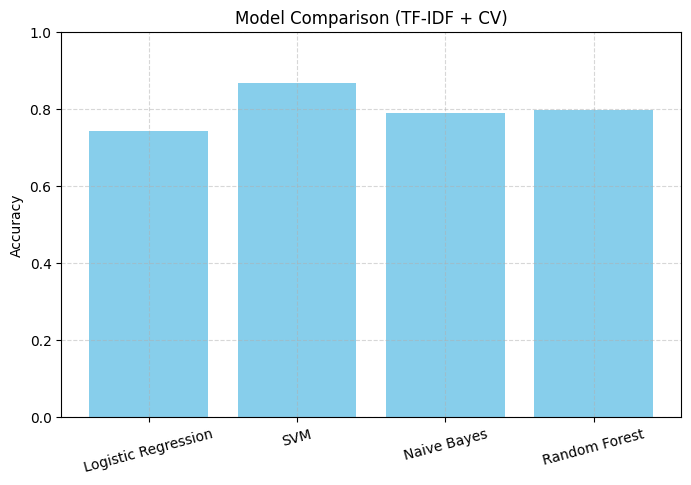

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Re-run models to store scores
model_scores = {}
best_model = None
best_score = 0

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    model_scores[name] = np.mean(scores)
    print(f"\n=== {name} ===")
    print(f"Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")
    if np.mean(scores) > best_score:
        best_score = np.mean(scores)
        best_model = model

# Plot accuracy scores
plt.figure(figsize=(8, 5))
plt.bar(model_scores.keys(), model_scores.values(), color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Comparison (TF-IDF + CV)")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


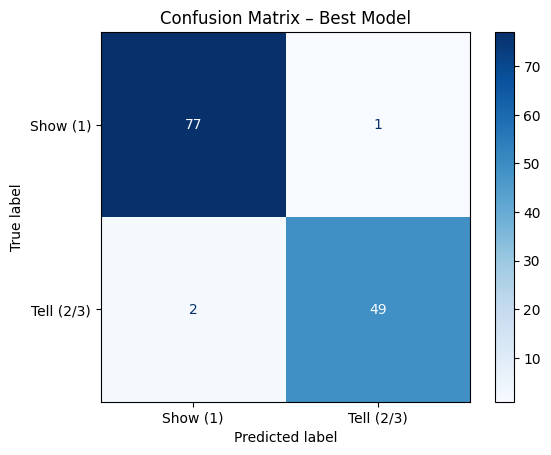

In [10]:
# Train best model on full data to show confusion matrix
best_model.fit(X, y)
y_pred = best_model.predict(X)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Show (1)", "Tell (2/3)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Best Model")
plt.show()
